In [48]:
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

In [49]:
df = pd.read_csv("final_dataset.csv")
df = df.sample(3000)
print(df.head())
print(df.emotion.unique())

                                                     text     emotion
103175  i respectfully call upon my friend and fellow ...     neutral
35676   i normally have this i thought i was supposed ...         fun
4510    the video on myspace is so funny...u run a lot...         fun
21641   i got out from the hot shower feeling invigora...  enthusiasm
67832   i feel reassured that god is real and has a se...     neutral
<ArrowStringArray>
[   'neutral',        'fun', 'enthusiasm',  'happiness',      'empty',
      'anger',       'love',    'sadness',       'hate',   'surprise',
     'relief']
Length: 11, dtype: str


In [50]:
df['emotion'] = df['emotion'].replace({
    'empty': 'sadness',
    'relief': 'happiness',
    'enthusiasm': 'happiness',
    'fun': 'happiness'
})

In [51]:
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['emotion'])

num_labels = len(label_encoder.classes_)
print(label_encoder.classes_)

['anger' 'happiness' 'hate' 'love' 'neutral' 'sadness' 'surprise']


In [52]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

In [53]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [54]:
def tokenize(texts):
    return tokenizer(
        list(texts),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)

In [55]:
train_dataset = Dataset.from_dict({
    **train_encodings,
    "labels": train_labels.tolist()
})

val_dataset = Dataset.from_dict({
    **val_encodings,
    "labels": val_labels.tolist()
})

In [56]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=num_labels
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6044.10it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [57]:
training_args = TrainingArguments(
    output_dir='./results',
    do_eval=True,
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=10,
    logging_dir='./logs'
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [58]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    accuracy = (predictions == labels).mean()
    return {"accuracy": accuracy}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [59]:
trainer.train()

c:\Users\Shubham\emotion-quote-bert\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
10,1.953847
20,1.815131
30,1.750666
40,1.735177
50,1.728028
60,1.672953
70,1.762360
80,1.737253
90,1.624427
100,1.652040


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]
c:\Users\Shubham\emotion-quote-bert\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.08it/s]


TrainOutput(global_step=300, training_loss=1.412528206507365, metrics={'train_runtime': 1522.7583, 'train_samples_per_second': 3.152, 'train_steps_per_second': 0.197, 'total_flos': 189941819760000.0, 'train_loss': 1.412528206507365, 'epoch': 2.0})

In [60]:
import pickle

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Saved encoder ✅")

Saved encoder ✅


In [61]:
model.save_pretrained("bert_emotion_model")
tokenizer.save_pretrained("bert_emotion_model")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]


('bert_emotion_model\\tokenizer_config.json',
 'bert_emotion_model\\tokenizer.json')

In [62]:
def predict_emotion(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    return label_encoder.inverse_transform([pred])[0]

In [63]:
print(trainer.state.log_history[:5])

[{'loss': 1.9538467407226563, 'grad_norm': 5.1293253898620605, 'learning_rate': 1.94e-05, 'epoch': 0.06666666666666667, 'step': 10}, {'loss': 1.8151309967041016, 'grad_norm': 5.0562744140625, 'learning_rate': 1.8733333333333336e-05, 'epoch': 0.13333333333333333, 'step': 20}, {'loss': 1.7506658554077148, 'grad_norm': 3.6660616397857666, 'learning_rate': 1.8066666666666668e-05, 'epoch': 0.2, 'step': 30}, {'loss': 1.7351766586303712, 'grad_norm': 6.136179447174072, 'learning_rate': 1.7400000000000003e-05, 'epoch': 0.26666666666666666, 'step': 40}, {'loss': 1.7280277252197265, 'grad_norm': 6.244297504425049, 'learning_rate': 1.6733333333333335e-05, 'epoch': 0.3333333333333333, 'step': 50}]


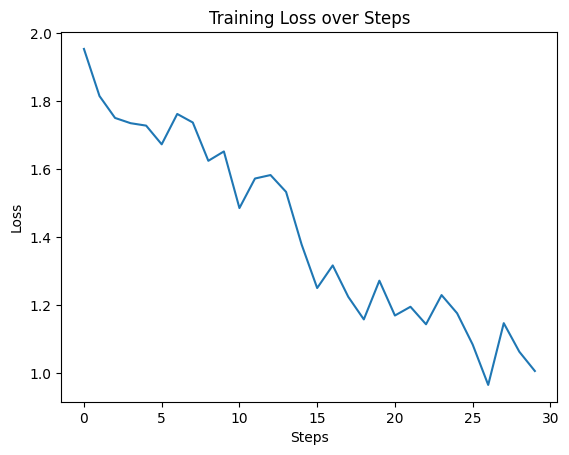

In [64]:
import matplotlib.pyplot as plt

# Get logs
logs = trainer.state.log_history

# Extract loss
train_loss = [x["loss"] for x in logs if "loss" in x]

plt.figure()
plt.plot(train_loss)
plt.title("Training Loss over Steps")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.show()

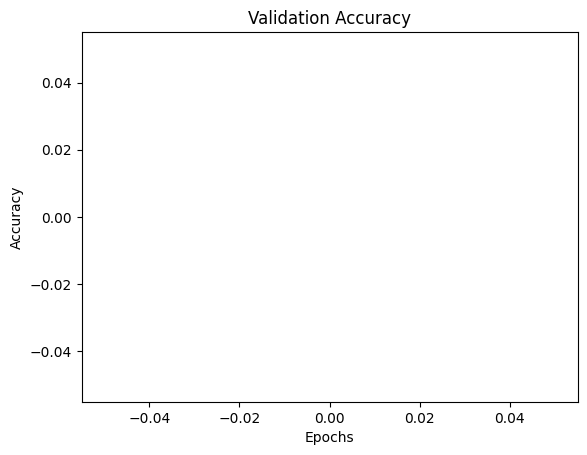

In [67]:
eval_acc = [x["eval_accuracy"] for x in logs if "eval_accuracy" in x]

plt.figure()
plt.plot(eval_acc)
plt.title("Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

c:\Users\Shubham\emotion-quote-bert\venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


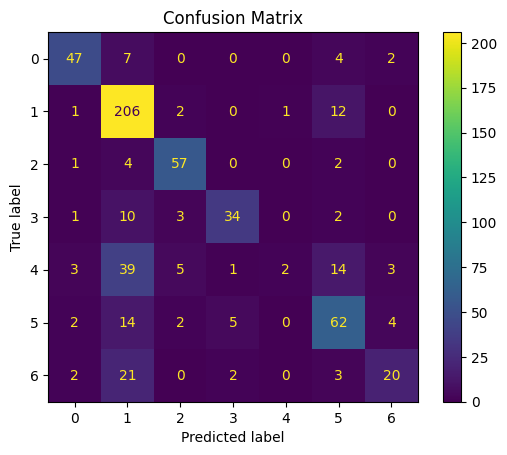

In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions
preds = trainer.predict(val_dataset)
y_pred = preds.predictions.argmax(axis=1)
y_true = preds.label_ids

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
df['emotion'].value_counts().plot(kind='bar')
plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

: 

: 

: 